In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Data Loading and Description

In [48]:
data = pd.read_csv('../data/raw/data.csv')
data_us = data[data['caller_country'] == 'United States']

state_names = [
    'Alabama', 'Alaska', 'Arizona', 'Arkansas', 'California', 'Colorado',
    'Connecticut', 'Delaware', 'Florida', 'Georgia', 'Hawaii', 'Idaho',
    'Illinois', 'Indiana', 'Iowa', 'Kansas', 'Kentucky', 'Louisiana',
    'Maine', 'Maryland', 'Massachusetts', 'Michigan', 'Minnesota',
    'Mississippi', 'Missouri', 'Montana', 'Nebraska', 'Nevada',
    'New Hampshire', 'New Jersey', 'New Mexico', 'New York',
    'North Carolina', 'North Dakota', 'Ohio', 'Oklahoma', 'Oregon',
    'Pennsylvania', 'Rhode Island', 'South Carolina', 'South Dakota',
    'Tennessee', 'Texas', 'Utah', 'Vermont', 'Virginia', 'Washington',
    'West Virginia', 'Wisconsin', 'Wyoming'
]

data_state = data_us[data_us['caller_state'].isin(state_names)]

In [49]:
print("Number of states:" ,data_state["caller_state"].nunique())
print("Columns in the dataset:", data_state.columns.tolist())

Number of states: 50
Columns in the dataset: ['year', 'month', 'contact_type', 'caller_state', 'caller_country', 'item', 'item_detail', 'count']


In [50]:
# what are in the item and item detail columns
for col in ['item', 'item_detail']:
    print(f"Unique values in '{col}':", data_state[col].unique())

Unique values in 'item': <StringArray>
['total_volume']
Length: 1, dtype: str
Unique values in 'item_detail': <StringArray>
['Total']
Length: 1, dtype: str


# State - Year Level

## Yearly Coverage

In [51]:
# should be 11 years for each state
data_state.groupby('caller_state')['year'].nunique().sort_values()

caller_state
Alabama           11
Nevada            11
New Hampshire     11
New Jersey        11
New Mexico        11
New York          11
North Carolina    11
North Dakota      11
Ohio              11
Oklahoma          11
Oregon            11
Pennsylvania      11
Rhode Island      11
South Carolina    11
South Dakota      11
Tennessee         11
Texas             11
Utah              11
Vermont           11
Virginia          11
Washington        11
West Virginia     11
Nebraska          11
Montana           11
Missouri          11
Mississippi       11
Alaska            11
Arizona           11
Arkansas          11
California        11
Colorado          11
Connecticut       11
Delaware          11
Florida           11
Georgia           11
Hawaii            11
Wisconsin         11
Idaho             11
Indiana           11
Iowa              11
Kansas            11
Kentucky          11
Louisiana         11
Maine             11
Maryland          11
Massachusetts     11
Michigan          11


## National Yearly Trend

<Axes: xlabel='year'>

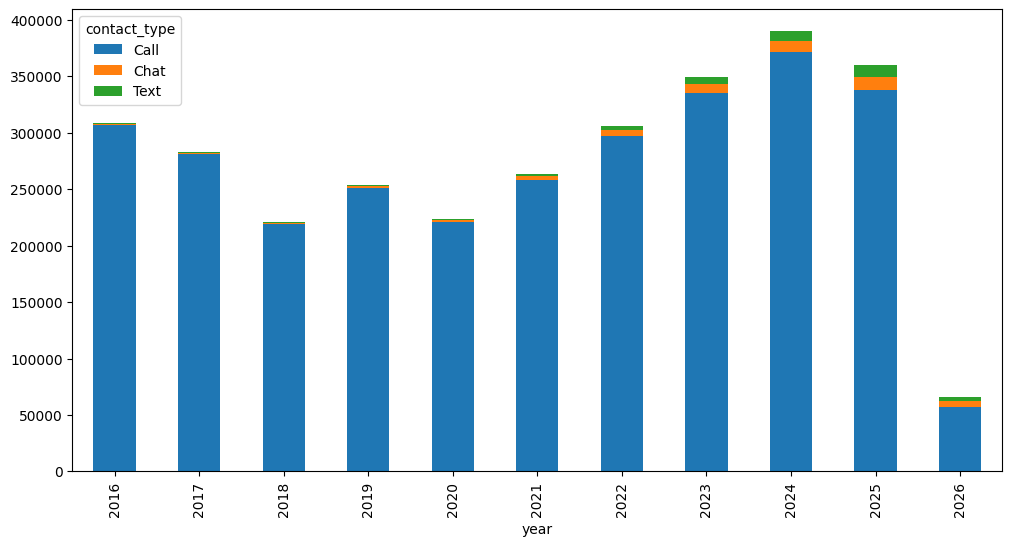

In [52]:
data_state.groupby(['year','contact_type'])["count"].sum().unstack().plot(kind='bar', stacked=True, figsize=(12, 6))

In [53]:
data_annual = data_state.groupby(['caller_state', 'year'])['count'].sum().reset_index(name="total_contacts")
state_totals = data_annual.groupby('caller_state')['total_contacts'].sum().sort_values(ascending=False)
print("Top 10:", state_totals.head(10))
print("Bottom 10:", state_totals.tail(10))

Top 10: caller_state
California      542381
Texas           268334
New York        185607
Illinois        176873
Pennsylvania    172370
Nevada          126477
New Jersey      117168
Florida         103076
Michigan         79712
Colorado         77402
Name: total_contacts, dtype: int64
Bottom 10: caller_state
Wyoming          7280
Delaware         7259
Rhode Island     6680
New Hampshire    5300
Vermont          4625
Maine            4579
Montana          4449
North Dakota     3647
Alaska           3222
South Dakota     2674
Name: total_contacts, dtype: int64


## Per state trend: do any states look weird?

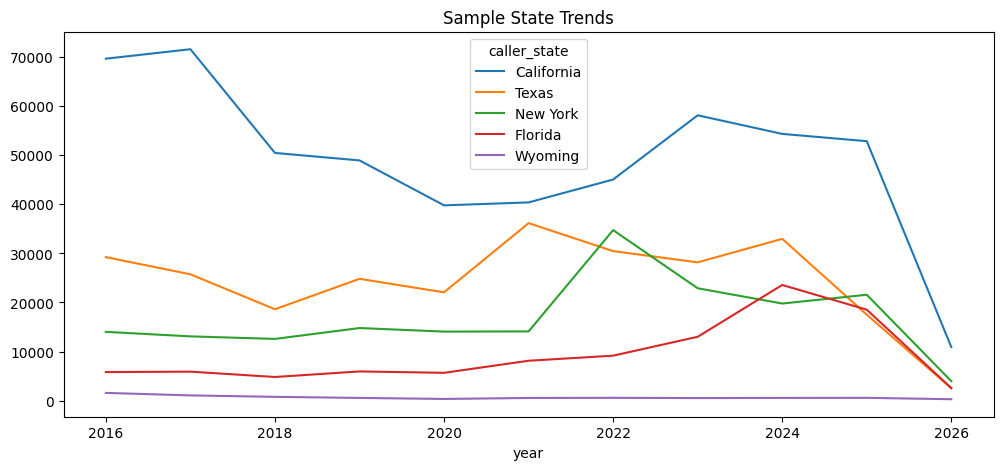

In [ ]:
pivot = data_annual.pivot(index='year', columns='caller_state', values='total_contacts')
pivot[['California','Texas','New York','Florida','Wyoming']].plot(figsize=(12,5), title='Sample State Trends')
plt.show()

## Year over year change nationally

In [24]:
national = data_annual.groupby('year')['total_contacts'].sum()
national_pct = national.pct_change() * 100
print(national_pct.round(2))

year
2016      NaN
2017    -8.20
2018   -21.97
2019    14.72
2020   -11.83
2021    18.03
2022    16.09
2023    14.20
2024    11.44
2025    -7.64
2026   -81.67
Name: total_contacts, dtype: float64


# State - Month Level

In [64]:
data_monthly = data_state.groupby(['caller_state', 'year', 'month'])['count'].sum().reset_index(name="total_contacts")
data_monthly['date'] = pd.to_datetime(data_monthly['year'].astype(str) + '-' + data_monthly['month'].astype(str))
data_monthly["month"] = data_monthly['date'].dt.month


/var/folders/6p/5s7l8jtj05s_1p_1jxzg33480000gn/T/ipykernel_21807/3622696327.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data_monthly['date'] = pd.to_datetime(data_monthly['year'].astype(str) + '-' + data_monthly['month'].astype(str))


## Monthly Coverage


In [65]:
data_monthly.groupby('caller_state')['date'].nunique().sort_values()

caller_state
South Dakota      116
Alabama           120
Nevada            120
New Hampshire     120
New Jersey        120
New Mexico        120
New York          120
North Carolina    120
North Dakota      120
Ohio              120
Oklahoma          120
Oregon            120
Pennsylvania      120
Rhode Island      120
South Carolina    120
Tennessee         120
Texas             120
Utah              120
Vermont           120
Virginia          120
Washington        120
West Virginia     120
Nebraska          120
Montana           120
Missouri          120
Mississippi       120
Alaska            120
Arizona           120
Arkansas          120
California        120
Colorado          120
Connecticut       120
Delaware          120
Florida           120
Georgia           120
Hawaii            120
Wisconsin         120
Idaho             120
Indiana           120
Iowa              120
Kansas            120
Kentucky          120
Louisiana         120
Maine             120
Maryland          1

## National Monthly Trend

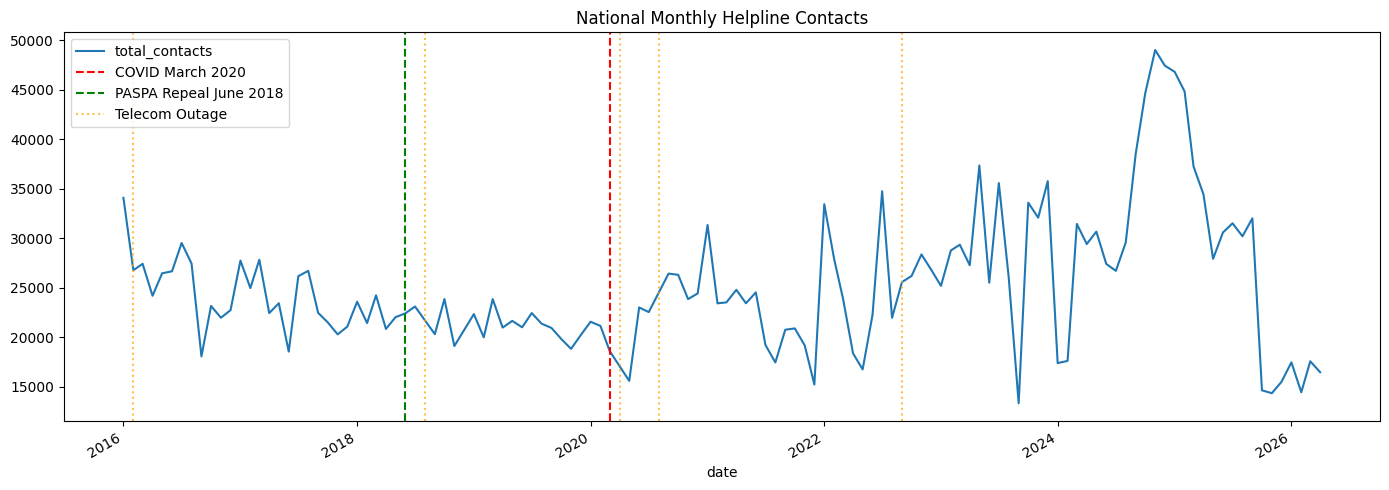

In [66]:
outage_dates = [
    pd.Timestamp('2016-02-01'),
    pd.Timestamp('2018-08-01'),
    pd.Timestamp('2020-04-01'),
    pd.Timestamp('2020-08-01'),
    pd.Timestamp('2022-09-01')
]

national_monthly = data_monthly.groupby('date')['total_contacts'].sum()
fig, ax = plt.subplots(figsize=(14, 5))
national_monthly.plot(ax=ax, title='National Monthly Helpline Contacts')

ax.axvline(pd.Timestamp('2020-03-01'), color='red', linestyle='--', label='COVID March 2020')
ax.axvline(pd.Timestamp('2018-06-01'), color='green', linestyle='--', label='PASPA Repeal June 2018')

for d in outage_dates:
    ax.axvline(d, color='orange', linestyle=':', alpha=0.7, label='Telecom Outage' if d == outage_dates[0] else '')

ax.legend()
plt.tight_layout()
plt.show()

## Seasonality Check

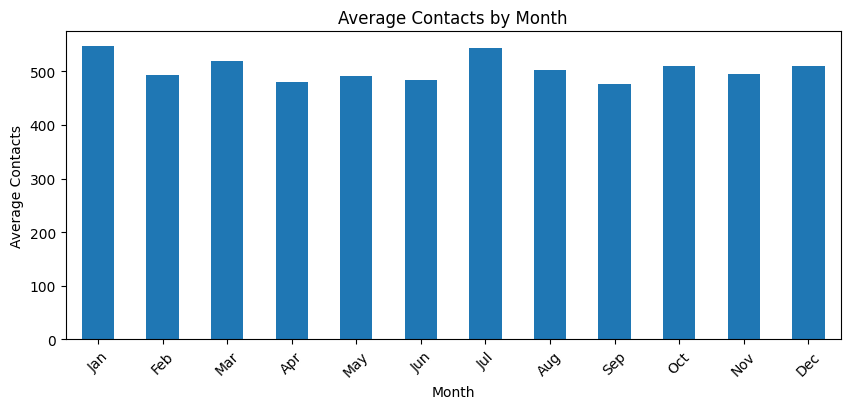

In [73]:
data_monthly.groupby('month')['total_contacts'].mean().plot(kind='bar', figsize=(10, 4), title='Average Contacts by Month')
plt.xlabel('Month')
plt.xticks(ticks=range(12), 
           labels=['Jan','Feb','Mar','Apr','May','Jun',
                   'Jul','Aug','Sep','Oct','Nov','Dec'], 
           rotation=45)
plt.ylabel('Average Contacts')
plt.show()


In [68]:
summary = data_monthly.groupby('caller_state')['total_contacts'].agg(['mean','median','std','min','max'])
summary.to_csv('../data/processed/state_summary_stats.csv')
data_annual.to_csv('../data/processed/helpline_annual.csv', index=False)
data_monthly.to_csv('../data/processed/helpline_monthly.csv', index=False)